In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully!")
print("LightGBM version:", lgb.__version__)

Libraries imported successfully!
LightGBM version: 4.7.0


In [5]:
import joblib

X_train_final = joblib.load(
    "../data/X_train_final_processed.pkl"
)

X_val_final = joblib.load(
    "../data/X_val_final_processed.pkl"
)

X_test_final = joblib.load(
    "../data/X_test_final_processed.pkl"
)

y_train = joblib.load(
    "../data/y_train_final.pkl"
)

y_val = joblib.load(
    "../data/y_val_final.pkl"
)

y_test = joblib.load(
    "../data/y_test_final.pkl"
)

print("Final datasets loaded!")

print("Train:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Final datasets loaded!
Train: (184506, 422)
Validation: (61502, 422)
Test: (61503, 422)
y_train: (184506,)
y_val: (61502,)
y_test: (61503,)


In [7]:
import numpy as np

X_train_full = np.vstack([
    X_train_final,
    X_val_final
])

y_train_full = np.concatenate([
    y_train,
    y_val
])

print("Combined training data:")
print("X:", X_train_full.shape)
print("y:", y_train_full.shape)

print("\nTarget distribution:")
print(pd.Series(y_train_full).value_counts())

Combined training data:
X: (246008, 422)
y: (246008,)

Target distribution:
0    226148
1     19860
Name: count, dtype: int64


In [8]:
final_model = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=731,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Final LightGBM model created!")

Final LightGBM model created!


In [9]:
final_model.fit(
    X_train_full,
    y_train_full
)

print("Final model training completed!")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105345 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30783
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Final model training completed!


In [10]:
y_test_proba = final_model.predict_proba(
    X_test_final
)[:, 1]

print("Test predictions generated!")

print("Number of predictions:", len(y_test_proba))

print("\nPrediction statistics:")
print("Minimum:", y_test_proba.min())
print("Maximum:", y_test_proba.max())
print("Mean:", y_test_proba.mean())

Test predictions generated!
Number of predictions: 61503

Prediction statistics:
Minimum: 0.002872126918489344
Maximum: 0.8682570215988423
Mean: 0.07946794412094561


In [11]:
test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print("=" * 60)
print("FINAL TEST PERFORMANCE")
print("=" * 60)

print(f"ROC-AUC: {test_roc_auc:.6f}")
print(f"PR-AUC:  {test_pr_auc:.6f}")

FINAL TEST PERFORMANCE
ROC-AUC: 0.788418
PR-AUC:  0.280048


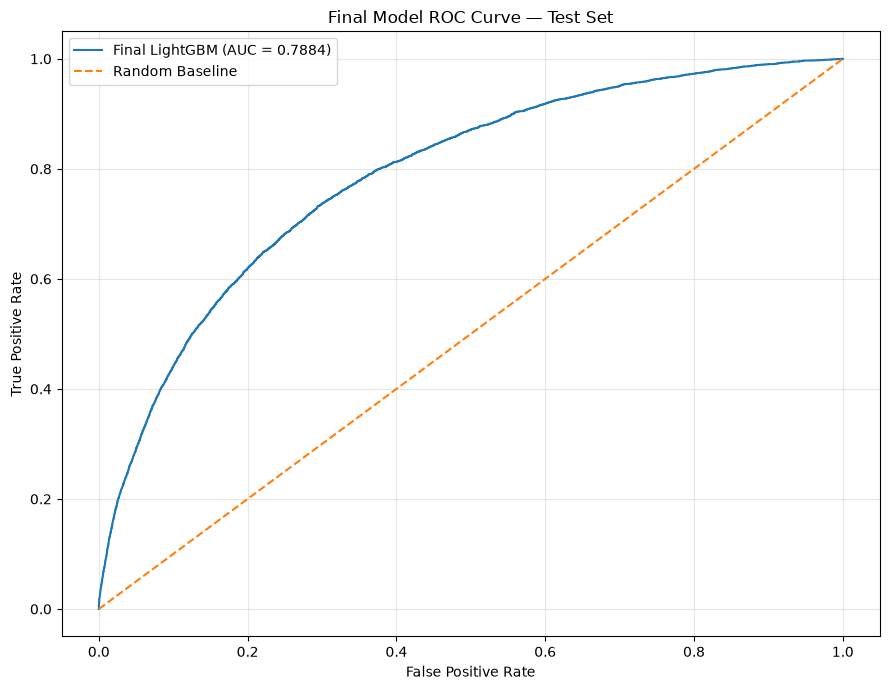

In [12]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr,
    tpr,
    label=f"Final LightGBM (AUC = {test_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model ROC Curve — Test Set")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

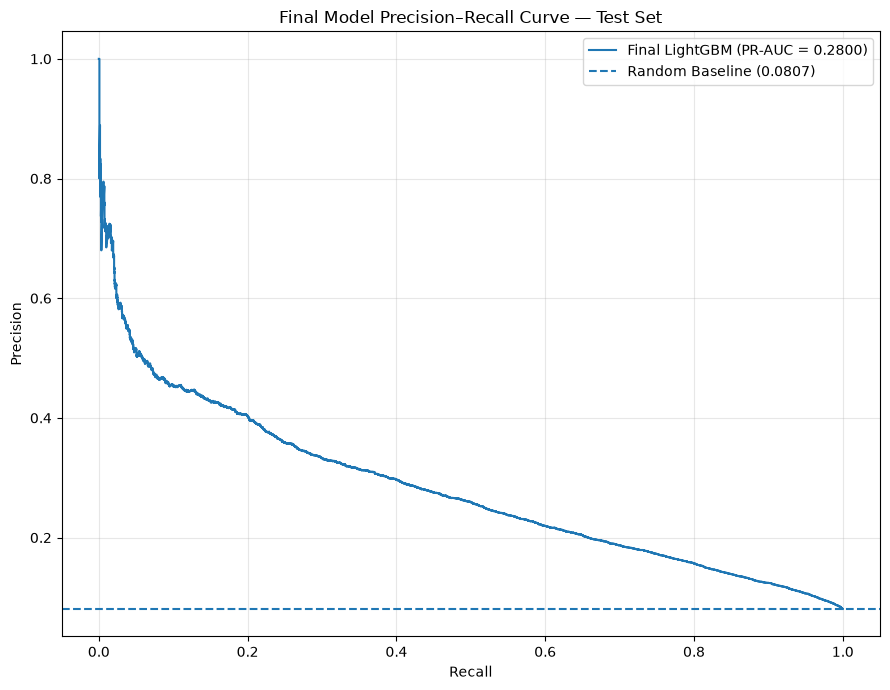

In [13]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(9, 7))

plt.plot(
    recall,
    precision,
    label=f"Final LightGBM (PR-AUC = {test_pr_auc:.4f})"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Random Baseline ({baseline:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Model Precision–Recall Curve — Test Set")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()